CNN

1: Importación de Librerías y Configuración del Entorno

In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, Rescaling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuración de reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"Versión de TensorFlow: {tf.__version__}")
# Verificar si hay GPU disponible (en WSL2 o entornos compatibles)
gpus = tf.config.list_physical_devices('GPU')
print(f"Dispositivos GPU disponibles: {gpus}")

Versión de TensorFlow: 2.21.0
Dispositivos GPU disponibles: []


2: Definición de Rutas e Hiperparámetros Globales

In [2]:
# Rutas del proyecto basadas en el árbol de directorios del Challenge 3
BASE_DIR = './x-rays'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
LEADERBOARD_DIR = os.path.join(BASE_DIR, 'leaderboard')
SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission_levi.csv')

# Hiperparámetros optimizados para imágenes de Rayos X médicos
IMG_SIZE = (150, 150)  # Dimensión estandarizada óptima
BATCH_SIZE = 32
EPOCHS = 40

3: Carga de Datos y Canalización con Data Augmentation

In [4]:
# Pipeline de Aumento de Datos para mitigar el sobreajuste
# Ayuda a que el modelo generalice mejor ante variaciones de rotación o zoom en las placas
data_augmentation = Sequential([
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

print("--- Cargando Dataset de Entrenamiento ---")
# 1. Creamos el dataset original
train_ds_base = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    color_mode='rgb'
)

# 2. EXTRAEMOS LAS CLASES AQUÍ (Antes de que se transforme en _MapDataset)
class_names = train_ds_base.class_names
print(f"\nClases detectadas con éxito en el dataset: {class_names}")

# 3. Aplicamos el Data Augmentation al set de entrenamiento
train_ds = train_ds_base.map(lambda x, y: (data_augmentation(x, training=True), y))


print("\n--- Cargando Dataset de Validación ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    color_mode='rgb'
)

print("\n--- Cargando Dataset de Test ---")
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    color_mode='rgb',
    shuffle=False  # Crucial mantener False para la evaluación métrica final
)

--- Cargando Dataset de Entrenamiento ---
Found 351 files belonging to 3 classes.

Clases detectadas con éxito en el dataset: ['COVID-19', 'HEALTHY', 'PNEUMONIA']

--- Cargando Dataset de Validación ---
Found 90 files belonging to 3 classes.

--- Cargando Dataset de Test ---
Found 96 files belonging to 3 classes.


4: Arquitectura del Modelo CNN Regularizado

In [5]:
# Construcción de una CNN Robusta con Regularización por Capas
model = Sequential([
    Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Normalización del rango de píxeles de [0, 255] a [0, 1]
    Rescaling(1./255),
    
    # Bloque Convolucional 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    
    # Bloque Convolucional 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Bloque Convolucional 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    # Bloque Convolucional 4 (Extracción de características abstractas)
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),
    
    # Capas de Clasificación (Dense / Fully Connected)
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 clases: COVID-19, HEALTHY, PNEUMONIA
])

# Compilación con tasa de aprendizaje estándar bien controlada
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,898,499 (11.06 MB)

 Trainable params: 2,897,283 (11.05 MB)

 Non-trainable params: 1,216 (4.75 KB)

5: Entrenamiento con Callbacks Inteligentes

In [6]:
# Callbacks dinámicos para evitar el sobreajuste y estancamientos
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=8, 
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=4, 
        min_lr=1e-6, 
        verbose=1
    )
]

# Entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40


C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6068 - loss: 1.2489 - val_accuracy: 0.3333 - val_loss: 1.5756 - learning_rate: 0.0010
Epoch 2/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7350 - loss: 0.7767 - val_accuracy: 0.3333 - val_loss: 3.2717 - learning_rate: 0.0010
Epoch 3/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7977 - loss: 0.6094 - val_accuracy: 0.3333 - val_loss: 4.9613 - learning_rate: 0.0010
Epoch 4/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8063 - loss: 0.5624 - val_accuracy: 0.3333 - val_loss: 5.0507 - learning_rate: 0.0010
Epoch 5/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8348 - loss: 0.4788
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8348 - loss: 0.4788 - val_accuracy: 0.3333 - val_loss: 5.9565 - learning_rate: 0.0010
Epoch 6/40
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8091 - loss: 0.5108 - val_accuracy: 0.3333 - val

6: Evaluación de Métricas en el Conjunto de Test

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step

--- INFORME DE CLASIFICACIÓN (Métricas en Test) ---
              precision    recall  f1-score   support

    COVID-19       0.00      0.00      0.00        32
     HEALTHY       0.00      0.00      0.00        32
   PNEUMONIA       0.33      1.00      0.50        32

    accuracy                           0.33        96
   macro avg       0.11      0.33      0.17        96
weighted avg       0.11      0.33      0.17        96



C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

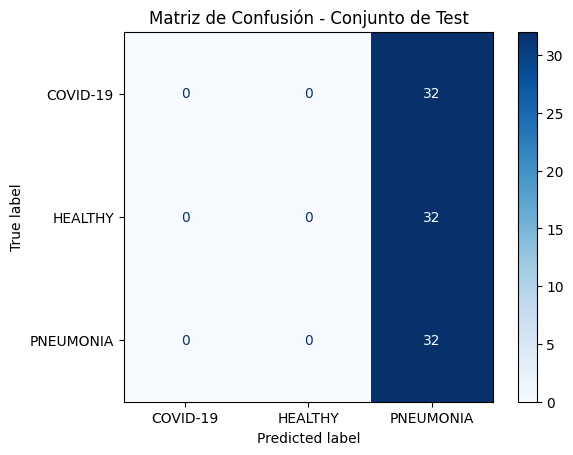

In [7]:
# Extraer etiquetas reales del set de prueba para contrastar
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_labels = np.argmax(y_true, axis=1)

# Realizar predicciones sobre el set de prueba
predictions = model.predict(test_ds)
y_pred_labels = np.argmax(predictions, axis=1)

# Informe de Clasificación Detallado
print("\n--- INFORME DE CLASIFICACIÓN (Métricas en Test) ---")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Matriz de Confusión Visual
cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Conjunto de Test")
plt.show()

7: Generación Corrección de Inferencia y Generación de Entrega (Leaderboard)

In [8]:
def natural_sort_key(s):
    """Función clave para ordenar cadenas de texto numéricas de manera natural (1, 2, 3... 100, 101)"""
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def generar_submission_ordenada(modelo, directorio_leaderboard, ruta_guardado_csv):
    """
    Lee las imágenes del leaderboard aplicando ordenamiento numérico estricto,
    realiza la predicción con el modelo entrenado y exporta el archivo .csv estructurado.
    """
    # 1. Listar y ordenar de manera natural los archivos de la carpeta
    archivos = [f for f in os.listdir(directorio_leaderboard) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    archivos.sort(key=natural_sort_key)
    
    ids_lista = []
    predicciones_lista = []
    
    print(f"Procesando {len(archivos)} imágenes del Leaderboard en orden numérico estricto...")
    
    for idx, nombre_archivo in enumerate(archivos):
        # Extraer el ID numérico del nombre del archivo (ej: '10.png' -> 10)
        id_numerico = int(os.path.splitext(nombre_archivo)[0])
        ruta_completa = os.path.join(directorio_leaderboard, nombre_archivo)
        
        # Cargar y preprocesar la imagen de manera idéntica al flujo de entrenamiento
        img = load_img(ruta_completa, target_size=IMG_SIZE, color_mode='rgb')
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Añadir dimensión de batch (1, 150, 150, 3)
        
        # Realizar la inferencia
        pred_prob = modelo.predict(img_array, verbose=0)
        clase_predicha = np.argmax(pred_prob, axis=1)[0]
        
        ids_lista.append(id_numerico)
        predicciones_lista.append(clase_predicha)
        
        # Traza de control para asegurar visualmente el orden correcto
        if idx < 5 or idx >= len(archivos) - 5:
            print(f"Archivo: {nombre_archivo} -> ID Asignado: {id_numerico} -> Clase Predicha: {clase_predicha}")
        elif idx == 5:
            print("...")

    # 2. Construir DataFrame y Guardar CSV
    df_submission = pd.DataFrame({
        'id': ids_lista,
        'prediction': predicciones_lista
    })
    
    # Guardar sin índice para mantener el formato plano requerido por el concurso
    df_submission.to_csv(ruta_guardado_csv, index=False)
    print(f"\n¡Éxito total! Archivo generado correctamente en: {ruta_guardado_csv}")
    return df_submission

# Ejecutar el proceso de generación final
df_final = generar_submission_ordenada(model, LEADERBOARD_DIR, SUBMISSION_PATH)

print("\n--- Muestra de las primeras 10 filas del CSV final generado ---")
print(df_final.head(10))

Procesando 116 imágenes del Leaderboard en orden numérico estricto...
Archivo: 1.png -> ID Asignado: 1 -> Clase Predicha: 2
Archivo: 2.png -> ID Asignado: 2 -> Clase Predicha: 2
Archivo: 3.png -> ID Asignado: 3 -> Clase Predicha: 2
Archivo: 4.png -> ID Asignado: 4 -> Clase Predicha: 2
Archivo: 5.png -> ID Asignado: 5 -> Clase Predicha: 2
...
Archivo: 112.png -> ID Asignado: 112 -> Clase Predicha: 2
Archivo: 113.png -> ID Asignado: 113 -> Clase Predicha: 2
Archivo: 114.png -> ID Asignado: 114 -> Clase Predicha: 2
Archivo: 115.png -> ID Asignado: 115 -> Clase Predicha: 2
Archivo: 116.png -> ID Asignado: 116 -> Clase Predicha: 2

¡Éxito total! Archivo generado correctamente en: ./x-rays\submission_levi.csv

--- Muestra de las primeras 10 filas del CSV final generado ---
   id  prediction
0   1           2
1   2           2
2   3           2
3   4           2
4   5           2
5   6           2
6   7           2
7   8           2
8   9           2
9  10           2
